# 01 – Exploratory Data Analysis (EDA)

**PM2.5 Time Series: Factor Analysis & SARIMA**  
Dự án phân tích chuỗi thời gian PM2.5 với dữ liệu PRSA (Guanyuan, Bắc Kinh).

Notebook này gộp **EDA** và **tiền xử lý (data prep)**: khám phá dữ liệu chi tiết, xử lý missing, lưu `cleaned_data.csv` và toàn bộ figure → dùng cho **Factor Analysis** và **SARIMA**. (File `data_prep.py` đã bỏ; Step 1 chỉ còn EDA notebook.)

## 1. Thiết lập và đọc dữ liệu gốc

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Project root (parent of src/)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
INTERIM_DIR = ROOT / "data" / "interim"
EDA_FIG_DIR = ROOT / "reports" / "figures" / "01_eda"
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
pd.set_option("display.max_columns", 20)

print("Project root:", ROOT)
print("Raw data dir:", RAW_DIR)

Project root: e:\myself\GITHUB\pm25_sarima_project
Raw data dir: e:\myself\GITHUB\pm25_sarima_project\data\raw


In [2]:
# Load raw CSV (first .csv in data/raw/ if not specified)
csv_files = list(RAW_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV in {RAW_DIR}")
csv_path = csv_files[0]
df_raw = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.name}")
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv
Shape: (35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
5,6,2013,3,1,5,3.0,6.0,6.0,14.0,400.0,71.0,-2.2,1025.6,-19.6,0.0,N,3.7,Guanyuan
6,7,2013,3,1,6,6.0,6.0,6.0,20.0,400.0,66.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Guanyuan
7,8,2013,3,1,7,3.0,3.0,7.0,26.0,400.0,61.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Guanyuan
8,9,2013,3,1,8,3.0,6.0,9.0,37.0,500.0,50.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Guanyuan
9,10,2013,3,1,9,7.0,11.0,9.0,30.0,400.0,58.0,1.2,1028.5,-19.3,0.0,N,2.6,Guanyuan


In [3]:
# Create datetime index (year, month, day, hour hoặc cột datetime/date)
time_cols = ["year", "month", "day", "hour"]
if all(c in df_raw.columns for c in time_cols):
    df = df_raw.copy()
    df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]].astype(int))
    df = df.drop(columns=["year", "month", "day", "hour"], errors="ignore")
    df = df.set_index("datetime").sort_index()
else:
    for col in ["datetime", "date", "Date", "timestamp"]:
        if col in df_raw.columns:
            df = df_raw.copy()
            df[col] = pd.to_datetime(df[col])
            df = df.set_index(col).sort_index()
            break
    else:
        raise ValueError("Need columns: year, month, day, hour OR datetime/date")

print("Index:", df.index.min(), "->", df.index.max())
print("Columns:", list(df.columns))
df.head()

Index: 2013-03-01 00:00:00 -> 2017-02-28 23:00:00
Columns: ['No', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
2013-03-01 01:00:00,2,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2013-03-01 02:00:00,3,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
2013-03-01 03:00:00,4,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
2013-03-01 04:00:00,5,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


## 2. Missing value summary

,Missing,Percent (%)
CO,1753,5.00
O3,1173,3.35
NO2,659,1.88
PM2.5,616,1.76
SO2,474,1.35
PM10,429,1.22
wd,81,0.23
TEMP,20,0.06
PRES,20,0.06
DEWP,20,0.06


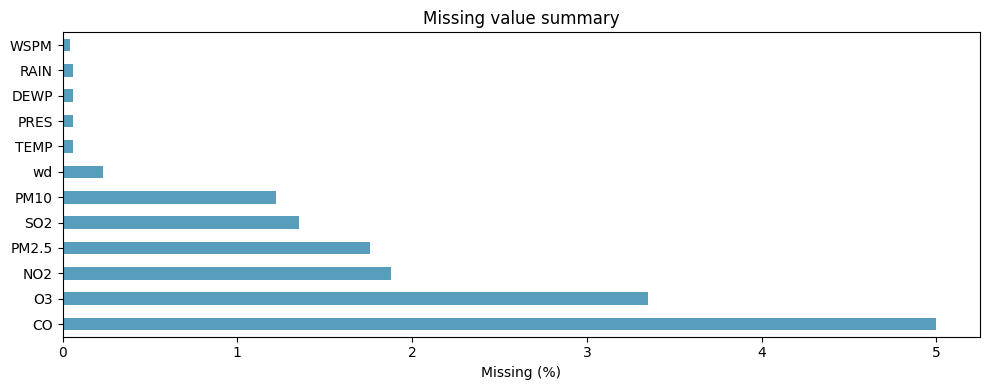

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing": missing,
    "Percent (%)": missing_pct
})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Missing", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df["Percent (%)"].plot(kind="barh", ax=ax, color="#2E86AB", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing value summary")
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / "missing_summary.png", bbox_inches="tight")
    plt.show()

## 3. Boxplot & distribution của PM2.5

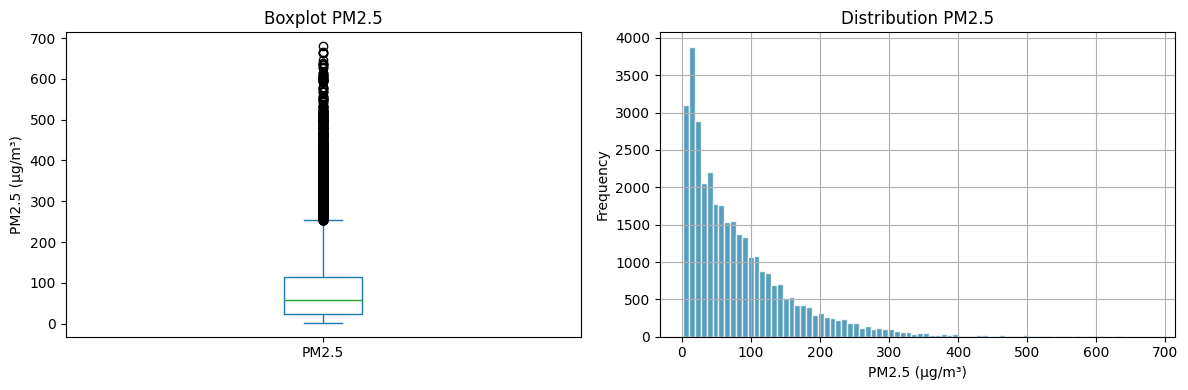

PM2.5 describe:
count    34448.000000
mean        82.933372
std         80.933497
min          2.000000
25%         23.000000
50%         59.000000
75%        115.000000
max        680.000000
Name: PM2.5, dtype: float64


In [5]:
pm25 = df["PM2.5"] if "PM2.5" in df.columns else df[[c for c in df.columns if "pm" in c.lower() and "2" in c][0]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pm25.plot(kind="box", ax=axes[0], vert=True)
axes[0].set_ylabel("PM2.5 (μg/m³)")
axes[0].set_title("Boxplot PM2.5")
pm25.hist(bins=80, ax=axes[1], color="#2E86AB", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("PM2.5 (μg/m³)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution PM2.5")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "pm25_boxplot_distribution.png", bbox_inches="tight")
plt.show()

print("PM2.5 describe:")
print(pm25.describe())

## 4. PM2.5 theo tháng

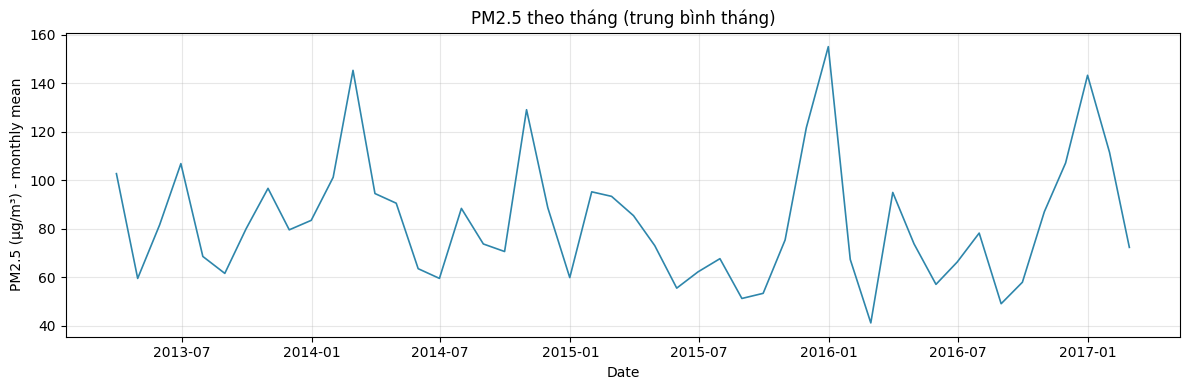

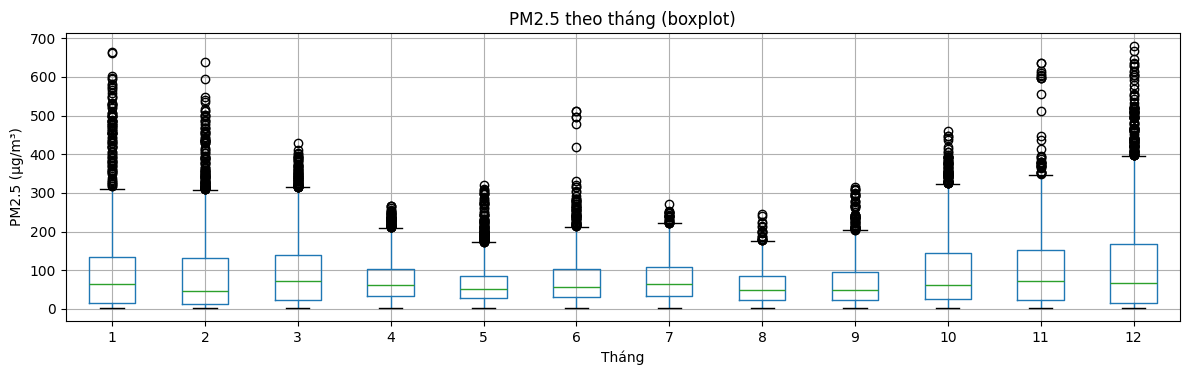

In [6]:
pm25_month = pm25.resample("ME").mean()  # end-of-month
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pm25_month.index, pm25_month.values, color="#2E86AB", linewidth=1.2)
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (μg/m³) - monthly mean")
ax.set_title("PM2.5 theo tháng (trung bình tháng)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "pm25_by_month.png", bbox_inches="tight")
plt.show()

# Box theo tháng (12 tháng)
df["month"] = df.index.month
fig, ax = plt.subplots(figsize=(12, 4))
df.boxplot(column="PM2.5", by="month", ax=ax)
ax.set_xlabel("Tháng")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title("PM2.5 theo tháng (boxplot)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "pm25_box_by_month.png", bbox_inches="tight")
plt.show()

## 5. PM2.5 theo giờ

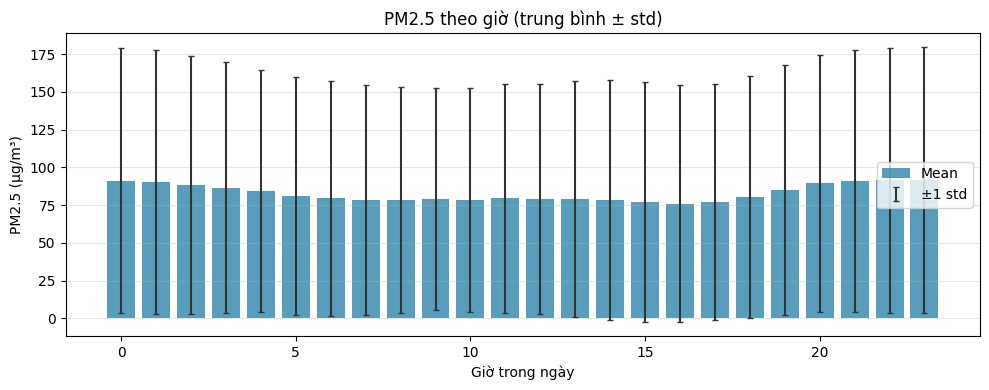

In [7]:
df["hour"] = df.index.hour
pm25_by_hour = df.groupby("hour")["PM2.5"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pm25_by_hour.index, pm25_by_hour["mean"], color="#2E86AB", alpha=0.8, label="Mean")
ax.errorbar(pm25_by_hour.index, pm25_by_hour["mean"], yerr=pm25_by_hour["std"], 
            fmt="none", color="#333", capsize=2, label="±1 std")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title("PM2.5 theo giờ (trung bình ± std)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "pm25_by_hour.png", bbox_inches="tight")
plt.show()

## 6. Rolling mean & rolling std

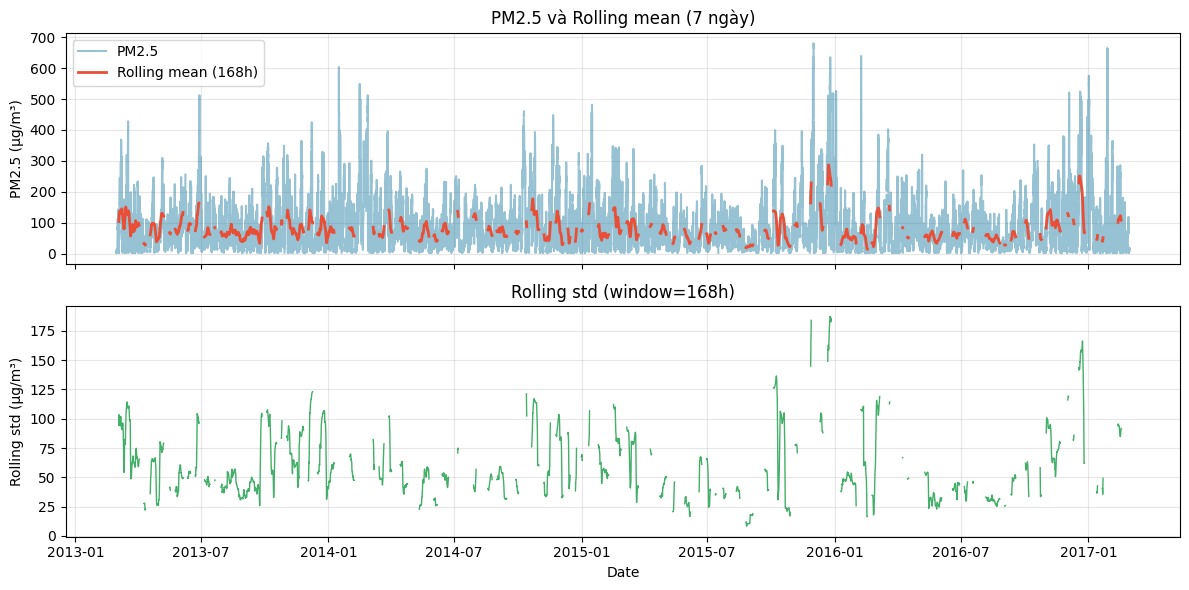

In [8]:
window = 24 * 7  # 7 ngày (hourly)
rolling_mean = pm25.rolling(window=window, center=True).mean()
rolling_std = pm25.rolling(window=window, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(pm25.index, pm25.values, alpha=0.5, label="PM2.5", color="#2E86AB")
axes[0].plot(rolling_mean.index, rolling_mean.values, color="#E94F37", linewidth=2, label=f"Rolling mean ({window}h)")
axes[0].set_ylabel("PM2.5 (μg/m³)")
axes[0].set_title("PM2.5 và Rolling mean (7 ngày)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rolling_std.index, rolling_std.values, color="#44AF69", linewidth=1)
axes[1].set_ylabel("Rolling std (μg/m³)")
axes[1].set_xlabel("Date")
axes[1].set_title(f"Rolling std (window={window}h)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "pm25_rolling_mean_std.png", bbox_inches="tight")
plt.show()

## 7. ACF & PACF

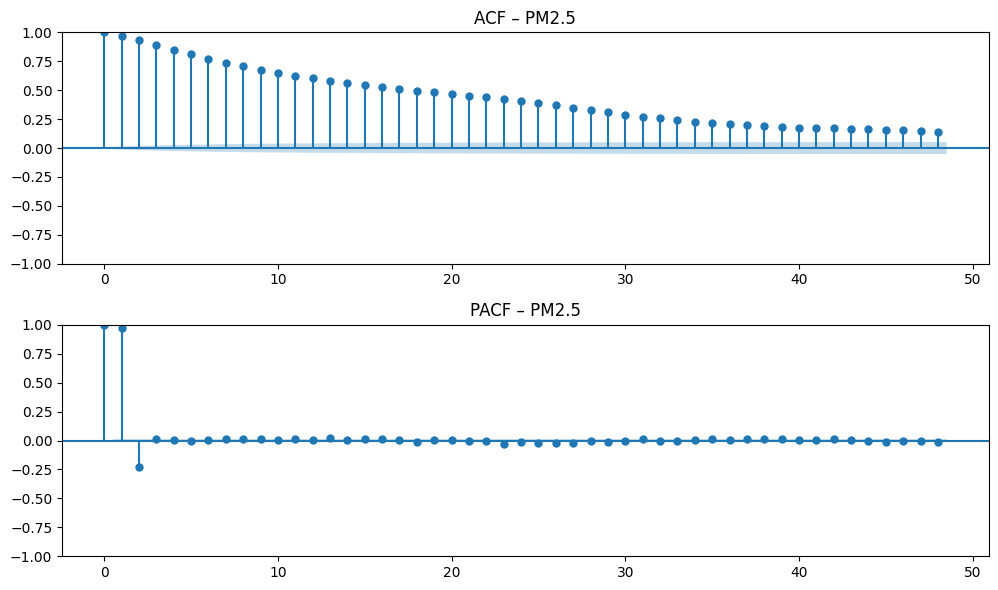

In [9]:
# ACF/PACF on PM2.5 (dropna for plot)
pm25_clean = pm25.dropna()
lags = 48  # 48 hours

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(pm25_clean, lags=lags, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF – PM2.5")
plot_pacf(pm25_clean, lags=lags, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF – PM2.5")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "acf_pacf_pm25.png", bbox_inches="tight")
plt.show()

## 8. Histogram các biến chính

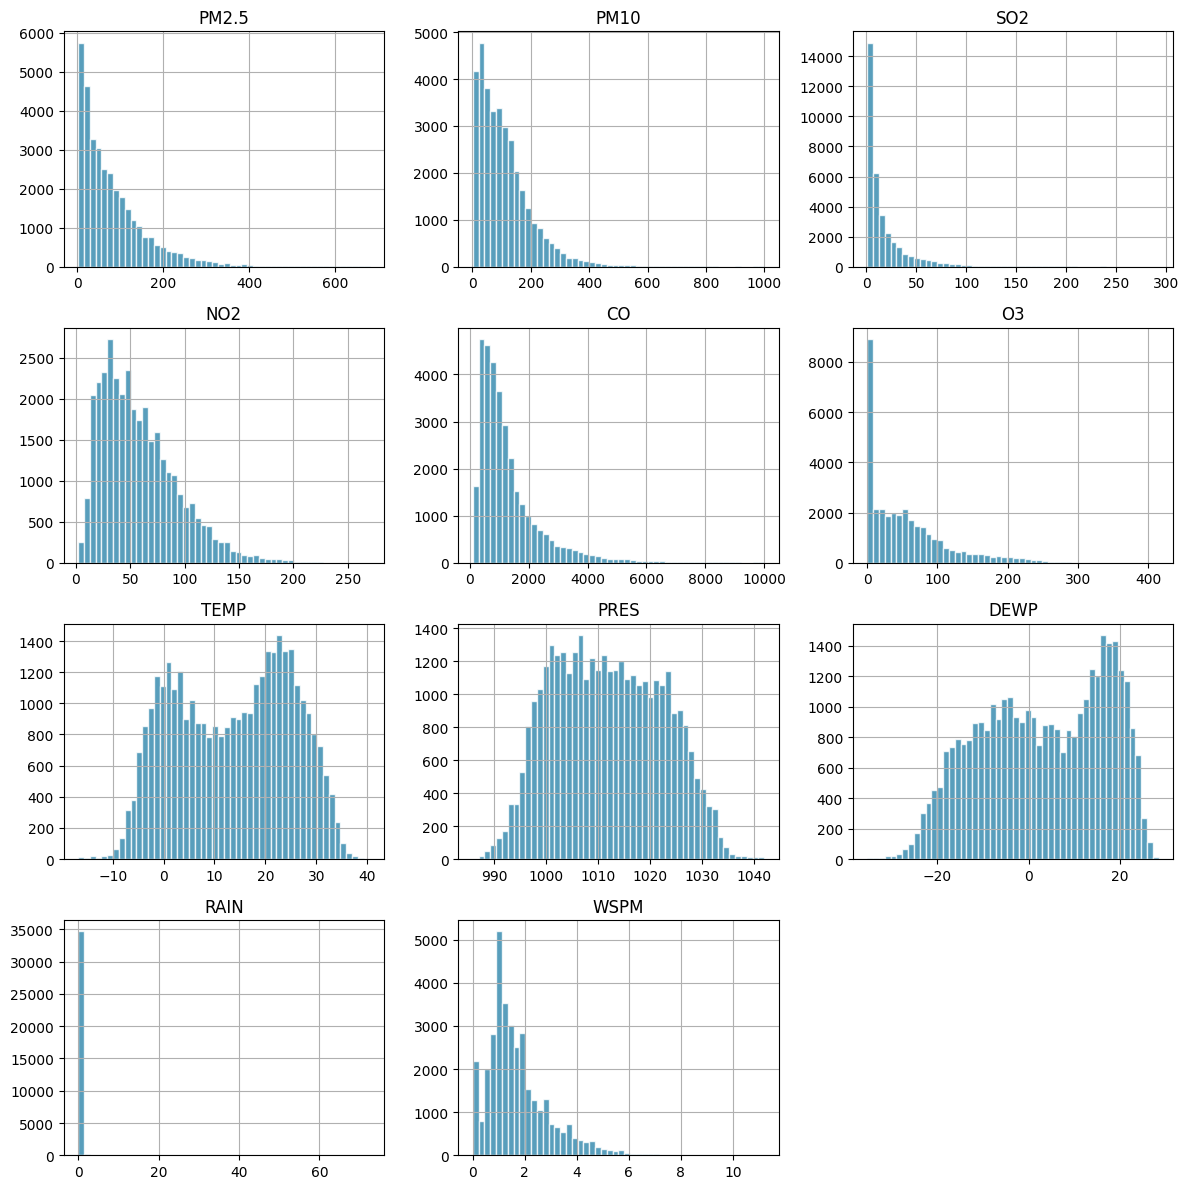

In [10]:
main_vars = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
main_vars = [v for v in main_vars if v in df.columns]

n = len(main_vars)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()
for i, col in enumerate(main_vars):
    df[col].hist(bins=50, ax=axes[i], color="#2E86AB", edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "histograms_main_vars.png", bbox_inches="tight")
plt.show()

## 9. Pairplot / Scatter với PM2.5

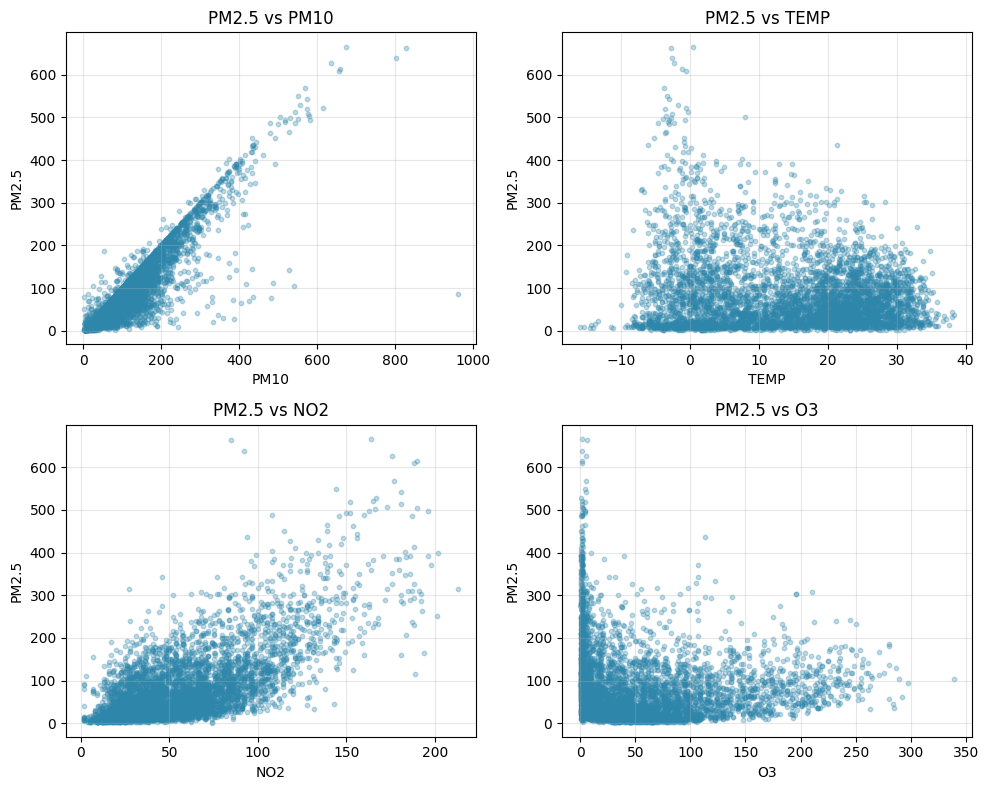

Correlation với PM2.5:
PM10    0.894751
CO      0.799166
NO2     0.691923
SO2     0.493186
DEWP    0.124896
PRES   -0.004928
RAIN   -0.010532
TEMP   -0.127831
O3     -0.140807
WSPM   -0.284336
Name: PM2.5, dtype: float64


In [11]:
# Scatter: PM2.5 vs một số biến quan trọng (sample để plot nhanh)
scatter_vars = ["PM10", "TEMP", "NO2", "O3"]
scatter_vars = [v for v in scatter_vars if v in df.columns]
sample_df = df[["PM2.5"] + scatter_vars].dropna().sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(scatter_vars):
    axes[i].scatter(sample_df[col], sample_df["PM2.5"], alpha=0.3, s=10, color="#2E86AB")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("PM2.5")
    axes[i].set_title(f"PM2.5 vs {col}")
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "scatter_pm25_vs_vars.png", bbox_inches="tight")
plt.show()

print("Correlation với PM2.5:")
corr_pm25 = df[main_vars].corr()["PM2.5"].drop("PM2.5").sort_values(ascending=False)
print(corr_pm25)

## 10. KMO & Bartlett (phù hợp cho Factor Analysis)

In [12]:
FA_VARS = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
fa_cols = [c for c in FA_VARS if c in df.columns]
X_fa = df[fa_cols].dropna()

if X_fa.shape[0] < 100:
    print("Not enough data after dropna for KMO/Bartlett.")
else:
    kmo_per_var, kmo_total = calculate_kmo(X_fa)
    print("KMO overall:", round(float(kmo_total), 4))
    print("KMO per variable:")
    print(kmo_per_var)
    chi2, p_value = calculate_bartlett_sphericity(X_fa)
    print("Bartlett: chi2 =", round(chi2, 2), ", p-value =", p_value)
    print("-> Dữ liệu phù hợp cho FA" if p_value < 0.05 else "-> Cần xem xét (p > 0.05)")

KMO overall: 0.7352
KMO per variable:
[0.74614741 0.85364287 0.75558842 0.7927352  0.702287   0.69272543
 0.86666314 0.64813163 0.3422508  0.56140476]
Bartlett: chi2 = 210894.17 , p-value = 0.0
-> Dữ liệu phù hợp cho FA


## 11. Decomposition & seasonal plot

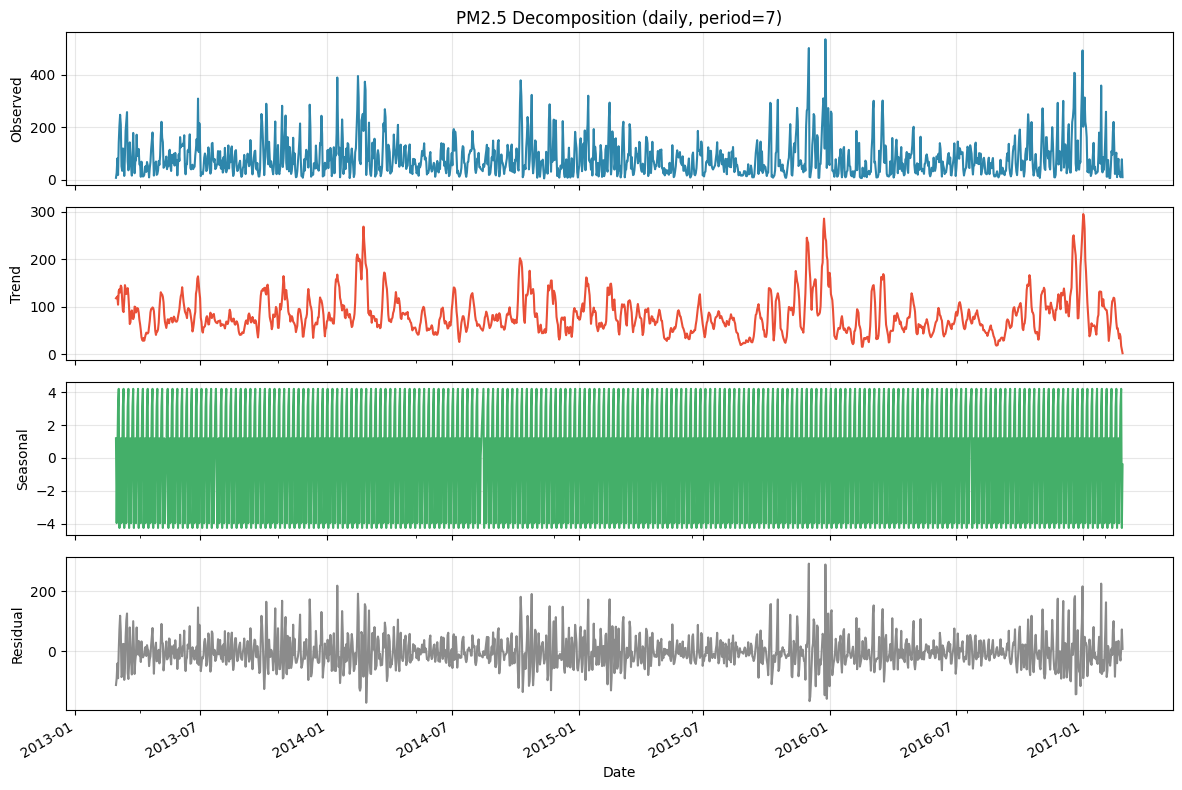

In [13]:
# Decomposition: daily aggregate (period=7 for weekly seasonality)
pm25_daily = pm25.resample("D").mean().dropna()
period = 7
decomp = seasonal_decompose(pm25_daily, model="additive", period=period, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomp.observed.plot(ax=axes[0], color="#2E86AB")
axes[0].set_ylabel("Observed")
axes[0].set_title("PM2.5 Decomposition (daily, period=7)")
decomp.trend.plot(ax=axes[1], color="#E94F37")
axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="#44AF69")
axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax=axes[3], color="#8B8B8B")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "decomposition_pm25_daily.png", bbox_inches="tight")
plt.show()

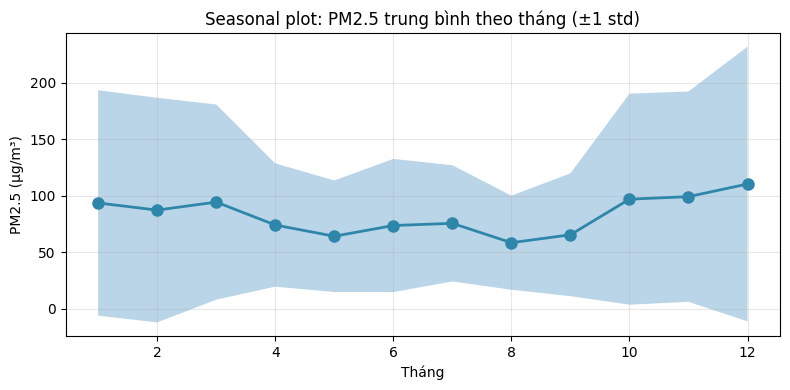

In [14]:
# Seasonal plot: PM2.5 by month (average across years)
df["month"] = df.index.month
seasonal = df.groupby("month")["PM2.5"].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seasonal.index, seasonal["mean"], "o-", color="#2E86AB", linewidth=2, markersize=8)
ax.fill_between(seasonal.index, seasonal["mean"] - seasonal["std"], seasonal["mean"] + seasonal["std"], alpha=0.3)
ax.set_xlabel("Tháng")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title("Seasonal plot: PM2.5 trung bình theo tháng (±1 std)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "seasonal_plot_pm25_by_month.png", bbox_inches="tight")
plt.show()

## 12. Time series PM2.5 & Correlation heatmap

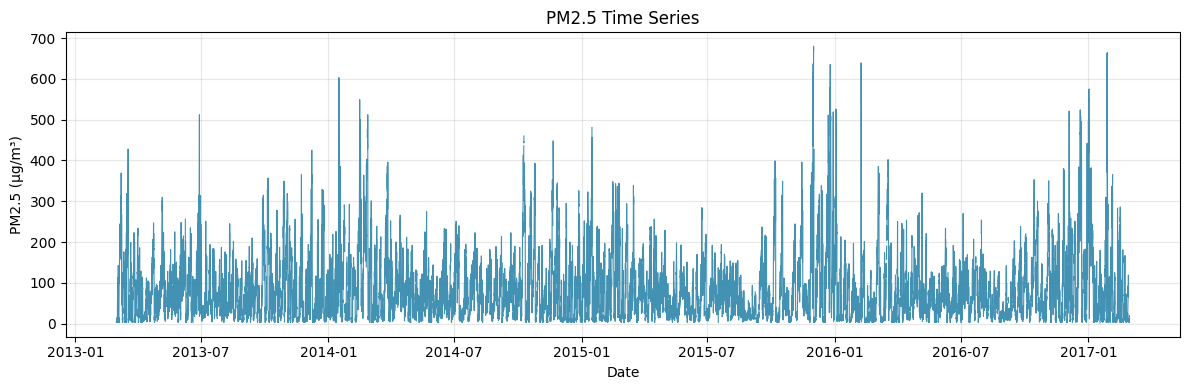

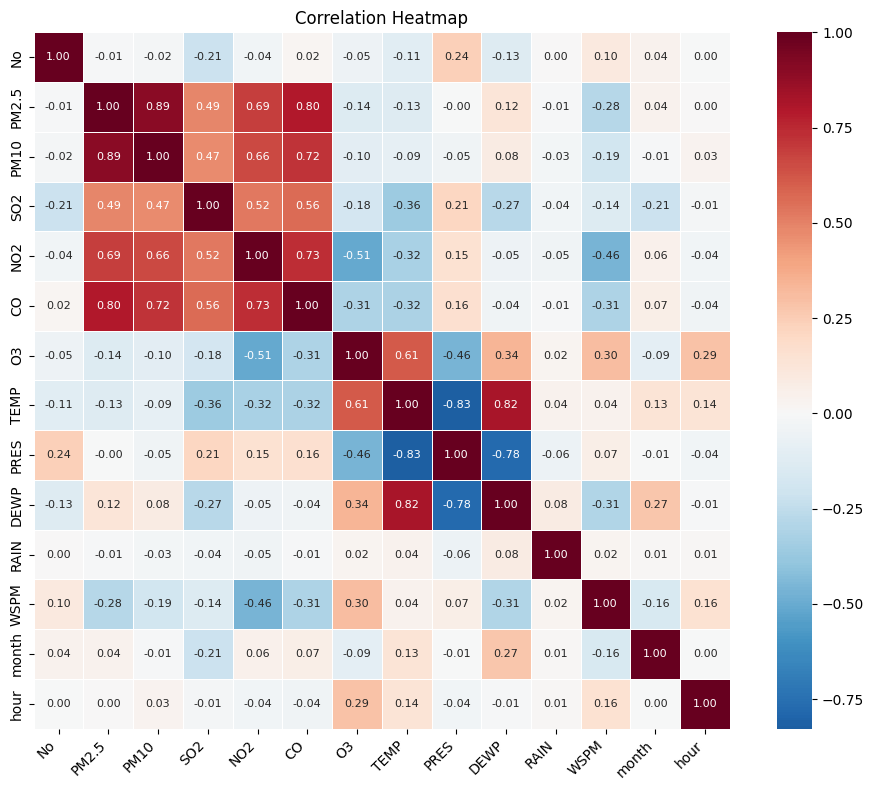

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["PM2.5"], color="#2E86AB", linewidth=0.8, alpha=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title("PM2.5 Time Series")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "pm25_time_series.png", bbox_inches="tight")
plt.show()

numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 13. Xử lý missing & lưu dữ liệu cho các bước sau

In [16]:
# Tiền xử lý (data prep): interpolation theo thời gian + ffill/bfill
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].interpolate(method="time")
df_clean = df_clean.ffill().bfill()

# Bỏ cột phụ chỉ dùng cho EDA (month, hour)
df_clean = df_clean.drop(columns=["month", "hour"], errors="ignore")

out_path = INTERIM_DIR / "cleaned_data.csv"
df_clean.to_csv(out_path)
print(f"Saved cleaned data to {out_path}")
print(f"Shape: {df_clean.shape}")
print("Missing after cleaning:", df_clean.isnull().sum().sum())

Saved cleaned data to e:\myself\GITHUB\pm25_sarima_project\data\interim\cleaned_data.csv
Shape: (35064, 14)
Missing after cleaning: 0


Sau khi chạy xong notebook:
- **cleaned_data.csv** đã được lưu tại `data/interim/` → dùng cho **Factor Analysis** và **SARIMA**.
- Các biểu đồ EDA nằm trong `reports/figures/01_eda/`.
- Chạy pipeline tiếp: `python main.py` (sẽ dùng sẵn cleaned_data nếu có).

## 14. Stationarity tests, station analysis và seasonal ACF/PACF

Trong phần này, ta đánh giá tính dừng và cấu trúc mùa vụ của chuỗi PM2.5 (daily):

- Augmented Dickey-Fuller (ADF)
- KPSS
- Station analysis (decomposition + pattern theo tháng/ngày trong tuần)
- Lag plot
- Seasonal ACF/PACF (mùa vụ tuần, m = 7)

Các kết quả này dùng để biện minh cho việc xây dựng mô hình SARIMA trên chuỗi **daily** với **seasonality 7 ngày**.

In [17]:
# Tạo chuỗi PM2.5 daily dùng chung cho các phân tích bên dưới
pm25_hourly = df["PM2.5"].astype(float)
pm25_daily = pm25_hourly.resample("D").mean().dropna()

print("Hourly length:", len(pm25_hourly))
print("Daily length :", len(pm25_daily))
pm25_daily.head()

Hourly length: 35064
Daily length : 1456


datetime
2013-03-01      7.541667
2013-03-02     26.375000
2013-03-03     81.500000
2013-03-04     18.250000
2013-03-05    141.166667
Name: PM2.5, dtype: float64

In [18]:
# 1️⃣ ADF test cho PM2.5 daily
from statsmodels.tsa.stattools import adfuller, kpss

adf_result = adfuller(pm25_daily, autolag="AIC")
adf_stat, adf_pvalue, adf_usedlag, adf_nobs, adf_crit, adf_icbest = adf_result

print("Augmented Dickey-Fuller Test (PM2.5 daily)")
print("------------------------------------------")
print(f"Test statistic : {adf_stat:.4f}")
print(f"p-value        : {adf_pvalue:.6f}")
print(f"Used lags      : {adf_usedlag}")
print(f"N observations : {adf_nobs}")
print("Critical values:")
for k, v in adf_crit.items():
    print(f"  {k}: {v:.4f}")
print(f"IC best (AIC)  : {adf_icbest:.4f}")

Augmented Dickey-Fuller Test (PM2.5 daily)
------------------------------------------
Test statistic : -17.6911
p-value        : 0.000000
Used lags      : 2
N observations : 1453
Critical values:
  1%: -3.4349
  5%: -2.8635
  10%: -2.5678
IC best (AIC)  : 15638.5976


In [19]:
# 2️⃣ KPSS test cho PM2.5 daily
kpss_stat, kpss_pvalue, kpss_lags, kpss_crit = kpss(pm25_daily, regression="c", nlags="auto")

print("KPSS Test (PM2.5 daily)")
print("------------------------")
print(f"Test statistic : {kpss_stat:.4f}")
print(f"p-value        : {kpss_pvalue:.6f}")
print(f"Used lags      : {kpss_lags}")
print("Critical values:")
for k, v in kpss_crit.items():
    print(f"  {k}: {v:.4f}")

KPSS Test (PM2.5 daily)
------------------------
Test statistic : 0.1160
p-value        : 0.100000
Used lags      : 13
Critical values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\admin\AppData\Local\Temp\ipykernel_30508\1223962322.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, kpss_crit = kpss(pm25_daily, regression="c", nlags="auto")


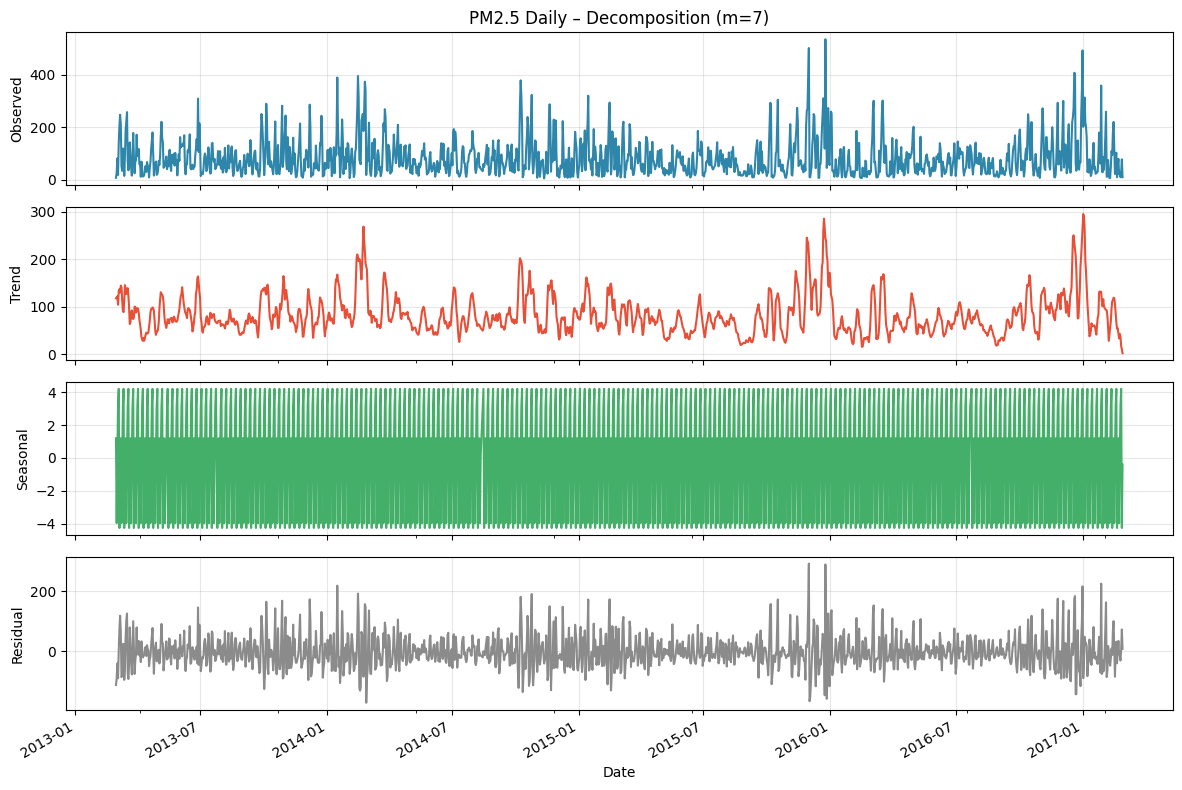

C:\Users\admin\AppData\Local\Temp\ipykernel_30508\2734673396.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pm25_daily_df, x="month", y="PM2.5", palette="Blues", ax=axes[0])
C:\Users\admin\AppData\Local\Temp\ipykernel_30508\2734673396.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pm25_daily_df, x="weekday", y="PM2.5", palette="Greens", ax=axes[1])


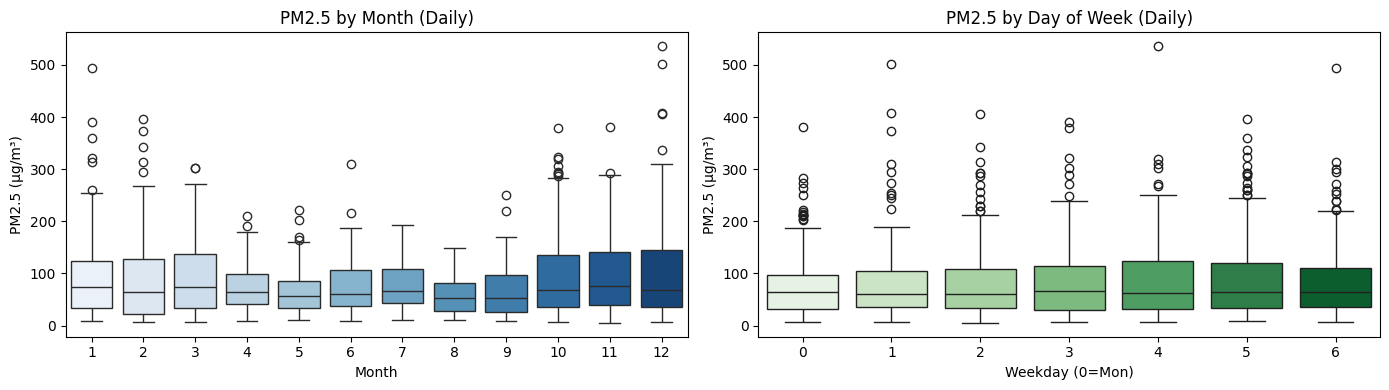

In [20]:
# 3️⃣ Station analysis: decomposition + pattern theo tháng / ngày trong tuần
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition với mùa vụ tuần (m = 7)
decomp = seasonal_decompose(pm25_daily, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomp.observed.plot(ax=axes[0], color="#2E86AB")
axes[0].set_ylabel("Observed")
axes[0].set_title("PM2.5 Daily – Decomposition (m=7)")

decomp.trend.plot(ax=axes[1], color="#E94F37")
axes[1].set_ylabel("Trend")

decomp.seasonal.plot(ax=axes[2], color="#44AF69")
axes[2].set_ylabel("Seasonal")

decomp.resid.plot(ax=axes[3], color="#8B8B8B")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mùa vụ theo tháng & theo ngày trong tuần (daily)
pm25_daily_df = pm25_daily.to_frame(name="PM2.5")
pm25_daily_df["month"] = pm25_daily_df.index.month
pm25_daily_df["weekday"] = pm25_daily_df.index.dayofweek  # 0=Mon, 6=Sun

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=pm25_daily_df, x="month", y="PM2.5", palette="Blues", ax=axes[0])
axes[0].set_title("PM2.5 by Month (Daily)", fontsize=12)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("PM2.5 (μg/m³)")

sns.boxplot(data=pm25_daily_df, x="weekday", y="PM2.5", palette="Greens", ax=axes[1])
axes[1].set_title("PM2.5 by Day of Week (Daily)", fontsize=12)
axes[1].set_xlabel("Weekday (0=Mon)")
axes[1].set_ylabel("PM2.5 (μg/m³)")

plt.tight_layout()
plt.show()

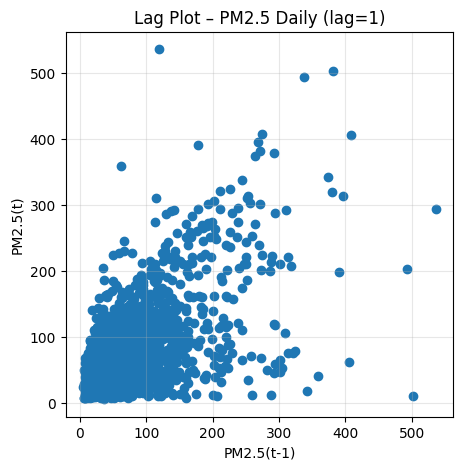

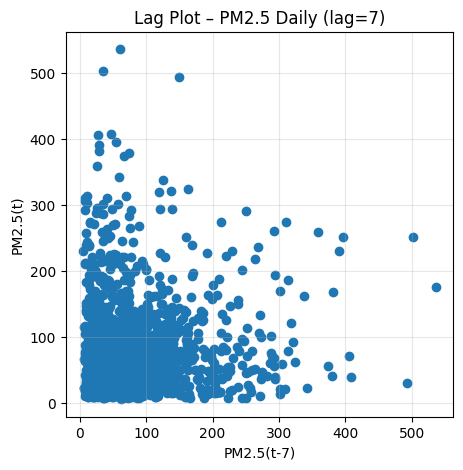

In [21]:
# 4️⃣ Lag plots cho PM2.5 daily
from pandas.plotting import lag_plot

plt.figure(figsize=(5, 5))
lag_plot(pm25_daily, lag=1)
plt.title("Lag Plot – PM2.5 Daily (lag=1)")
plt.xlabel("PM2.5(t-1)")
plt.ylabel("PM2.5(t)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(5, 5))
lag_plot(pm25_daily, lag=7)
plt.title("Lag Plot – PM2.5 Daily (lag=7)")
plt.xlabel("PM2.5(t-7)")
plt.ylabel("PM2.5(t)")
plt.grid(True, alpha=0.3)
plt.show()